# **1. Limits**

## Definition
A **limit** describes the value that a function approaches as the input approaches a particular value.

$$\lim_{x \to a} f(x) = L$$

This means: as $x$ gets arbitrarily close to $a$, $f(x)$ gets arbitrarily close to $L$.

## Why Limits Matter in Data Science
- Foundation for understanding **derivatives** (rates of change)
- Essential for **gradient descent** optimization
- Used in **probability distributions** and statistical analysis

## Types of Limits

| Type | Notation | Description |
|------|----------|-------------|
| **Two-sided** | $\lim_{x \to a} f(x)$ | Approaching from both left and right |
| **Left-sided** | $\lim_{x \to a^-} f(x)$ | Approaching from values less than $a$ |
| **Right-sided** | $\lim_{x \to a^+} f(x)$ | Approaching from values greater than $a$ |
| **At infinity** | $\lim_{x \to \infty} f(x)$ | Behavior as $x$ grows without bound |

## Key Limit Properties

If $\lim_{x \to a} f(x) = L$ and $\lim_{x \to a} g(x) = M$, then:

| Property | Formula |
|----------|--------|
| **Sum** | $\lim_{x \to a} [f(x) + g(x)] = L + M$ |
| **Product** | $\lim_{x \to a} [f(x) \cdot g(x)] = L \cdot M$ |
| **Quotient** | $\lim_{x \to a} \frac{f(x)}{g(x)} = \frac{L}{M}$ (if $M \neq 0$) |
| **Power** | $\lim_{x \to a} [f(x)]^n = L^n$ |
| **Constant** | $\lim_{x \to a} c \cdot f(x) = c \cdot L$ |

In [12]:
# ===============================================
# LIMITS WITH SYMPY
# ===============================================

from sympy import *
import numpy as np
import matplotlib.pyplot as plt

# Define symbol
x = symbols('x')

print("=" * 50)
print("COMPUTING LIMITS WITH SYMPY")
print("=" * 50)

# Example 1: Simple polynomial limit
f1 = x**2 + 3*x - 2
lim1 = limit(f1, x, 2)
print(f"\n1. lim(x→2) [x² + 3x - 2] = {lim1}")

# Example 2: Limit involving division (would be 0/0 at x=1)
f2 = (x**2 - 1)/(x - 1)
lim2 = limit(f2, x, 1)
print(f"\n2. lim(x→1) [(x²-1)/(x-1)] = {lim2}")
print("   Note: Direct substitution gives 0/0, but limit exists!")

# Example 3: Limit at infinity
f3 = (2*x**2 + 3)/(x**2 + 1)
lim3 = limit(f3, x, oo)
print(f"\n3. lim(x→∞) [(2x²+3)/(x²+1)] = {lim3}")

# Example 4: One-sided limits
f4 = 1/x
lim4_right = limit(f4, x, 0, '+')
lim4_left = limit(f4, x, 0, '-')
print(f"\n4. lim(x→0⁺) [1/x] = {lim4_right}")
print(f"   lim(x→0⁻) [1/x] = {lim4_left}")

COMPUTING LIMITS WITH SYMPY

1. lim(x→2) [x² + 3x - 2] = 8

2. lim(x→1) [(x²-1)/(x-1)] = 2
   Note: Direct substitution gives 0/0, but limit exists!

3. lim(x→∞) [(2x²+3)/(x²+1)] = 2

4. lim(x→0⁺) [1/x] = oo
   lim(x→0⁻) [1/x] = -oo


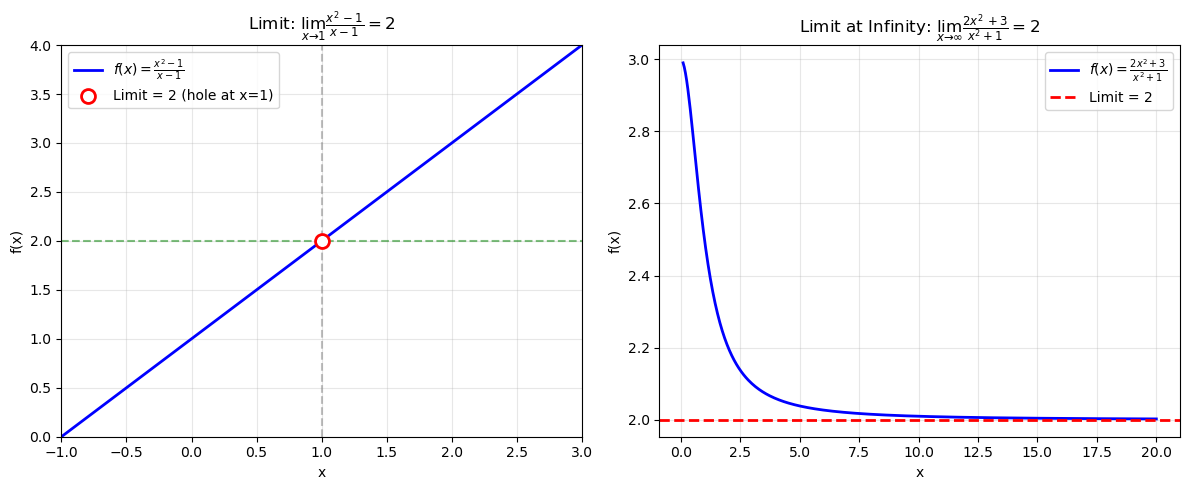

In [13]:
# ===============================================
# VISUALIZING LIMITS
# ===============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Limit as x approaches 1 for (x²-1)/(x-1)
ax1 = axes[0]
x_vals = np.linspace(-1, 3, 400)
# Avoid division by zero at x=1
x_vals = x_vals[np.abs(x_vals - 1) > 0.01]
y_vals = (x_vals**2 - 1)/(x_vals - 1)

ax1.plot(x_vals, y_vals, 'b-', linewidth=2, label=r'$f(x) = \frac{x^2-1}{x-1}$')
ax1.scatter([1], [2], color='red', s=100, zorder=5, 
            facecolors='white', edgecolors='red', linewidth=2,
            label='Limit = 2 (hole at x=1)')
ax1.axhline(y=2, color='green', linestyle='--', alpha=0.5)
ax1.axvline(x=1, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title(r'Limit: $\lim_{x \to 1} \frac{x^2-1}{x-1} = 2$')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-1, 3)
ax1.set_ylim(0, 4)

# Plot 2: Limit at infinity
ax2 = axes[1]
x_vals2 = np.linspace(0.1, 20, 400)
y_vals2 = (2*x_vals2**2 + 3)/(x_vals2**2 + 1)

ax2.plot(x_vals2, y_vals2, 'b-', linewidth=2, label=r'$f(x) = \frac{2x^2+3}{x^2+1}$')
ax2.axhline(y=2, color='red', linestyle='--', linewidth=2, label='Limit = 2')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title(r'Limit at Infinity: $\lim_{x \to \infty} \frac{2x^2+3}{x^2+1} = 2$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# **2. Derivatives**

## Definition
The **derivative** measures the instantaneous rate of change of a function. It's defined as:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

### Notation
| Notation | Meaning |
|----------|--------|
| $f'(x)$ | Lagrange notation |
| $\frac{df}{dx}$ | Leibniz notation |
| $\frac{dy}{dx}$ | Rate of change of $y$ with respect to $x$ |
| $\dot{y}$ | Newton's notation (time derivatives) |

## Why Derivatives Matter in Data Science
- **Gradient Descent**: Finding optimal parameters in machine learning
- **Optimization**: Minimizing loss functions
- **Neural Networks**: Backpropagation uses derivatives
- **Sensitivity Analysis**: How small changes affect outcomes

## Basic Derivative Rules

| Rule | Function | Derivative |
|------|----------|------------|
| **Constant** | $f(x) = c$ | $f'(x) = 0$ |
| **Power Rule** | $f(x) = x^n$ | $f'(x) = nx^{n-1}$ |
| **Exponential** | $f(x) = e^x$ | $f'(x) = e^x$ |
| **Natural Log** | $f(x) = \ln(x)$ | $f'(x) = \frac{1}{x}$ |
| **Sine** | $f(x) = \sin(x)$ | $f'(x) = \cos(x)$ |
| **Cosine** | $f(x) = \cos(x)$ | $f'(x) = -\sin(x)$ |

## Derivative Operation Rules

| Rule | Formula |
|------|--------|
| **Sum Rule** | $(f + g)' = f' + g'$ |
| **Difference Rule** | $(f - g)' = f' - g'$ |
| **Product Rule** | $(f \cdot g)' = f' \cdot g + f \cdot g'$ |
| **Quotient Rule** | $\left(\frac{f}{g}\right)' = \frac{f' \cdot g - f \cdot g'}{g^2}$ |

In [14]:
# ===============================================
# DERIVATIVES WITH SYMPY
# ===============================================

from sympy import *

x = symbols('x')

print("=" * 50)
print("COMPUTING DERIVATIVES WITH SYMPY")
print("=" * 50)

# Example 1: Power rule
f1 = x**3 + 2*x**2 - 5*x + 7
df1 = diff(f1, x)
print(f"\n1. f(x) = x³ + 2x² - 5x + 7")
print(f"   f'(x) = {df1}")

# Example 2: Exponential and logarithm
f2 = exp(x) + log(x)
df2 = diff(f2, x)
print(f"\n2. f(x) = eˣ + ln(x)")
print(f"   f'(x) = {df2}")

# Example 3: Trigonometric functions
f3 = sin(x) * cos(x)
df3 = diff(f3, x)
df3_simplified = simplify(df3)
print(f"\n3. f(x) = sin(x)·cos(x)")
print(f"   f'(x) = {df3}")
print(f"   Simplified: {df3_simplified}")

# Example 4: Higher order derivatives
f4 = x**4 - 3*x**3 + 2*x**2
df4_1 = diff(f4, x)      # First derivative
df4_2 = diff(f4, x, 2)   # Second derivative
df4_3 = diff(f4, x, 3)   # Third derivative
print(f"\n4. f(x) = x⁴ - 3x³ + 2x²")
print(f"   f'(x) = {df4_1}")
print(f"   f''(x) = {df4_2}")
print(f"   f'''(x) = {df4_3}")

COMPUTING DERIVATIVES WITH SYMPY

1. f(x) = x³ + 2x² - 5x + 7
   f'(x) = 3*x**2 + 4*x - 5

2. f(x) = eˣ + ln(x)
   f'(x) = exp(x) + 1/x

3. f(x) = sin(x)·cos(x)
   f'(x) = -sin(x)**2 + cos(x)**2
   Simplified: cos(2*x)

4. f(x) = x⁴ - 3x³ + 2x²
   f'(x) = 4*x**3 - 9*x**2 + 4*x
   f''(x) = 2*(6*x**2 - 9*x + 2)
   f'''(x) = 6*(4*x - 3)


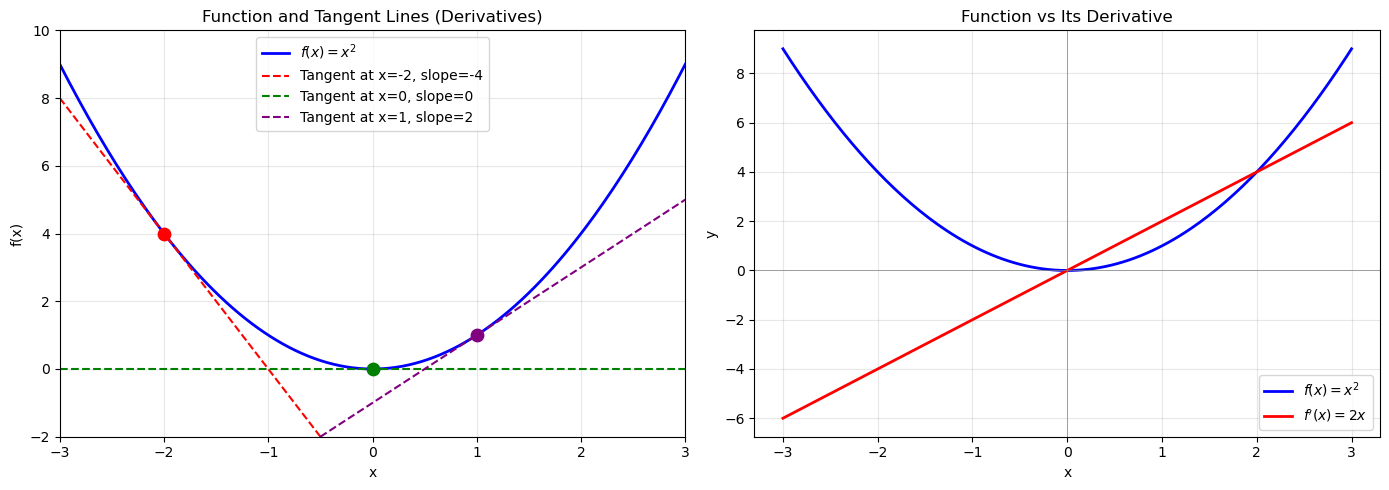

In [15]:
# ===============================================
# VISUALIZING DERIVATIVES: SLOPE OF TANGENT LINE
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from sympy import *

x = symbols('x')

# Define function and its derivative
f = x**2
f_prime = diff(f, x)

# Convert to numpy functions
f_num = lambdify(x, f, 'numpy')
f_prime_num = lambdify(x, f_prime, 'numpy')

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Function with tangent lines
ax1 = axes[0]
x_vals = np.linspace(-3, 3, 200)
ax1.plot(x_vals, f_num(x_vals), 'b-', linewidth=2, label=r'$f(x) = x^2$')

# Add tangent lines at different points
for a, color in [(-2, 'red'), (0, 'green'), (1, 'purple')]:
    slope = f_prime_num(a)
    y_a = f_num(a)
    # Tangent line: y - y_a = slope * (x - a)
    tangent_y = slope * (x_vals - a) + y_a
    ax1.plot(x_vals, tangent_y, '--', color=color, linewidth=1.5, 
             label=f'Tangent at x={a}, slope={slope}')
    ax1.scatter([a], [y_a], color=color, s=80, zorder=5)

ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Function and Tangent Lines (Derivatives)')
ax1.legend(loc='upper center')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-3, 3)
ax1.set_ylim(-2, 10)

# Plot 2: Function and its derivative
ax2 = axes[1]
ax2.plot(x_vals, f_num(x_vals), 'b-', linewidth=2, label=r"$f(x) = x^2$")
ax2.plot(x_vals, f_prime_num(x_vals), 'r-', linewidth=2, label=r"$f'(x) = 2x$")
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Function vs Its Derivative')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# **3. Partial Derivatives**

## Definition
For functions of multiple variables, a **partial derivative** measures the rate of change with respect to ONE variable while holding all others constant.

For $f(x, y)$:
- $\frac{\partial f}{\partial x}$ = derivative with respect to $x$, treating $y$ as constant
- $\frac{\partial f}{\partial y}$ = derivative with respect to $y$, treating $x$ as constant

## Why Partial Derivatives Matter in Data Science
- **Gradient**: Vector of all partial derivatives → direction of steepest ascent
- **Gradient Descent**: Update parameters using $\theta = \theta - \alpha \nabla f(\theta)$
- **Multi-variable Optimization**: Loss functions depend on many parameters

## The Gradient
The **gradient** of $f(x_1, x_2, ..., x_n)$ is:

$$\nabla f = \left( \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, ..., \frac{\partial f}{\partial x_n} \right)$$

## Example
For $f(x, y) = x^2 + 2xy + y^3$:
- $\frac{\partial f}{\partial x} = 2x + 2y$
- $\frac{\partial f}{\partial y} = 2x + 3y^2$

In [16]:
# ===============================================
# PARTIAL DERIVATIVES WITH SYMPY
# ===============================================

from sympy import *

x, y, z = symbols('x y z')

print("=" * 50)
print("PARTIAL DERIVATIVES WITH SYMPY")
print("=" * 50)

# Example 1: Two variables
f1 = x**2 + 2*x*y + y**3
df1_dx = diff(f1, x)  # Partial with respect to x
df1_dy = diff(f1, y)  # Partial with respect to y

print(f"\n1. f(x,y) = x² + 2xy + y³")
print(f"   ∂f/∂x = {df1_dx}")
print(f"   ∂f/∂y = {df1_dy}")

# Example 2: Three variables (common in ML loss functions)
f2 = x**2 + y**2 + z**2  # Distance-like function
gradient = [diff(f2, var) for var in [x, y, z]]
print(f"\n2. f(x,y,z) = x² + y² + z²")
print(f"   Gradient ∇f = ({gradient[0]}, {gradient[1]}, {gradient[2]})")

# Example 3: Second order partial derivatives
f3 = x**3*y**2 + sin(x)*cos(y)
df3_dx = diff(f3, x)
df3_dxdx = diff(f3, x, 2)  # Second partial w.r.t. x
df3_dxdy = diff(f3, x, y)  # Mixed partial derivative

print(f"\n3. f(x,y) = x³y² + sin(x)cos(y)")
print(f"   ∂f/∂x = {df3_dx}")
print(f"   ∂²f/∂x² = {df3_dxdx}")
print(f"   ∂²f/∂x∂y = {df3_dxdy}")

PARTIAL DERIVATIVES WITH SYMPY

1. f(x,y) = x² + 2xy + y³
   ∂f/∂x = 2*x + 2*y
   ∂f/∂y = 2*x + 3*y**2

2. f(x,y,z) = x² + y² + z²
   Gradient ∇f = (2*x, 2*y, 2*z)

3. f(x,y) = x³y² + sin(x)cos(y)
   ∂f/∂x = 3*x**2*y**2 + cos(x)*cos(y)
   ∂²f/∂x² = 6*x*y**2 - sin(x)*cos(y)
   ∂²f/∂x∂y = 6*x**2*y - sin(y)*cos(x)


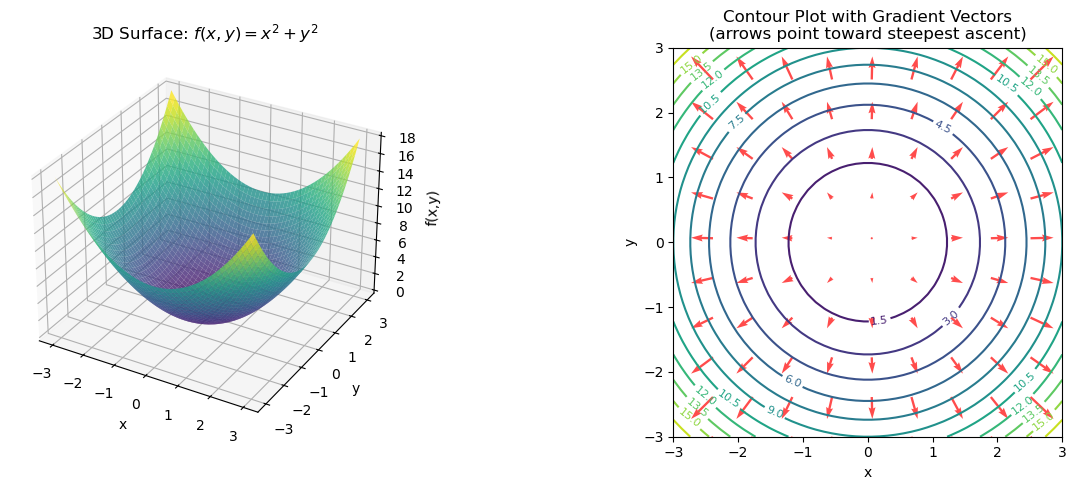

In [17]:
# ===============================================
# VISUALIZING GRADIENTS IN 3D
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a simple 2D function: f(x,y) = x² + y²
x_range = np.linspace(-3, 3, 50)
y_range = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

# Gradient: ∇f = (2x, 2y)
grad_x = 2*X
grad_y = 2*Y

fig = plt.figure(figsize=(14, 5))

# 3D Surface plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title(r'3D Surface: $f(x,y) = x^2 + y^2$')

# Contour plot with gradient field
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=15, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)

# Plot gradient arrows (subsample for clarity)
skip = 5
ax2.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
           grad_x[::skip, ::skip], grad_y[::skip, ::skip],
           color='red', alpha=0.7)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot with Gradient Vectors\n(arrows point toward steepest ascent)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

---
# **4. The Chain Rule**

## Definition
The **chain rule** is used to differentiate composite functions.

If $y = f(g(x))$, then:
$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx} = f'(g(x)) \cdot g'(x)$$

where $u = g(x)$.

## Why the Chain Rule Matters in Data Science
- **Backpropagation**: Core algorithm for training neural networks
- **Composite Models**: Many models are compositions of functions
- **Activation Functions**: Derivatives flow through network layers

## Examples

| Composite Function | Derivative |
|-------------------|------------|
| $(2x+1)^5$ | $5(2x+1)^4 \cdot 2 = 10(2x+1)^4$ |
| $e^{x^2}$ | $e^{x^2} \cdot 2x$ |
| $\sin(3x)$ | $\cos(3x) \cdot 3 = 3\cos(3x)$ |
| $\ln(x^2+1)$ | $\frac{1}{x^2+1} \cdot 2x = \frac{2x}{x^2+1}$ |

## Multivariable Chain Rule
For $z = f(x, y)$ where $x = x(t)$ and $y = y(t)$:

$$\frac{dz}{dt} = \frac{\partial f}{\partial x}\frac{dx}{dt} + \frac{\partial f}{\partial y}\frac{dy}{dt}$$

In [18]:
# ===============================================
# CHAIN RULE WITH SYMPY
# ===============================================

from sympy import *

x = symbols('x')

print("=" * 50)
print("CHAIN RULE WITH SYMPY")
print("=" * 50)

# Example 1: (2x+1)^5
f1 = (2*x + 1)**5
df1 = diff(f1, x)
print(f"\n1. f(x) = (2x + 1)⁵")
print(f"   f'(x) = {df1}")
print(f"   Simplified: {simplify(df1)}")

# Example 2: e^(x²)
f2 = exp(x**2)
df2 = diff(f2, x)
print(f"\n2. f(x) = e^(x²)")
print(f"   f'(x) = {df2}")

# Example 3: sin(3x)
f3 = sin(3*x)
df3 = diff(f3, x)
print(f"\n3. f(x) = sin(3x)")
print(f"   f'(x) = {df3}")

# Example 4: ln(x² + 1)
f4 = log(x**2 + 1)
df4 = diff(f4, x)
print(f"\n4. f(x) = ln(x² + 1)")
print(f"   f'(x) = {df4}")

# Example 5: Nested composition - sqrt(sin(x²))
f5 = sqrt(sin(x**2))
df5 = diff(f5, x)
print(f"\n5. f(x) = √(sin(x²))")
print(f"   f'(x) = {df5}")

CHAIN RULE WITH SYMPY

1. f(x) = (2x + 1)⁵
   f'(x) = 10*(2*x + 1)**4
   Simplified: 10*(2*x + 1)**4

2. f(x) = e^(x²)
   f'(x) = 2*x*exp(x**2)

3. f(x) = sin(3x)
   f'(x) = 3*cos(3*x)

4. f(x) = ln(x² + 1)
   f'(x) = 2*x/(x**2 + 1)

5. f(x) = √(sin(x²))
   f'(x) = x*cos(x**2)/sqrt(sin(x**2))


In [19]:
# ===============================================
# CHAIN RULE IN NEURAL NETWORKS (BACKPROPAGATION)
# ===============================================

from sympy import *

# Simple neural network: input → hidden → output
# y = sigmoid(w2 * sigmoid(w1 * x))

x, w1, w2 = symbols('x w1 w2')

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + exp(-z))

# Forward pass
z1 = w1 * x           # Hidden layer input
a1 = sigmoid(z1)      # Hidden layer activation
z2 = w2 * a1          # Output layer input
y_hat = sigmoid(z2)   # Output

print("=" * 50)
print("BACKPROPAGATION: Chain Rule in Neural Networks")
print("=" * 50)

print("\nSimple Network: x → (w1) → sigmoid → (w2) → sigmoid → y")

# Derivatives using chain rule (backpropagation)
dy_dw2 = diff(y_hat, w2)
dy_dw1 = diff(y_hat, w1)

print(f"\nOutput y = {y_hat}")
print(f"\n∂y/∂w2 = {simplify(dy_dw2)}")
print(f"\n∂y/∂w1 = {simplify(dy_dw1)}")

# Numerical example
print("\n" + "=" * 50)
print("Numerical Example: x=1, w1=0.5, w2=0.8")
print("=" * 50)
vals = {x: 1, w1: 0.5, w2: 0.8}
print(f"Output: {float(y_hat.subs(vals)):.6f}")
print(f"∂y/∂w2: {float(dy_dw2.subs(vals)):.6f}")
print(f"∂y/∂w1: {float(dy_dw1.subs(vals)):.6f}")

BACKPROPAGATION: Chain Rule in Neural Networks

Simple Network: x → (w1) → sigmoid → (w2) → sigmoid → y

Output y = 1/(1 + exp(-w2/(1 + exp(-w1*x))))

∂y/∂w2 = exp(w1*x + w2*exp(w1*x)/(exp(w1*x) + 1))/((exp(w1*x) + 1)*(exp(w2*exp(w1*x)/(exp(w1*x) + 1)) + 1)**2)

∂y/∂w1 = w2*x*exp(w1*x + w2*exp(w1*x)/(exp(w1*x) + 1))/((exp(w1*x) + 1)**2*(exp(w2*exp(w1*x)/(exp(w1*x) + 1)) + 1)**2)

Numerical Example: x=1, w1=0.5, w2=0.8
Output: 0.621982
∂y/∂w2: 0.146353
∂y/∂w1: 0.044203


---
# **5. Integrals**

## Definition
An **integral** is the reverse of differentiation. It calculates the area under a curve.

### Indefinite Integral (Antiderivative)
$$\int f(x) \, dx = F(x) + C$$
where $F'(x) = f(x)$ and $C$ is the constant of integration.

### Definite Integral
$$\int_a^b f(x) \, dx = F(b) - F(a)$$
This gives the area under $f(x)$ from $x = a$ to $x = b$.

## Why Integrals Matter in Data Science
- **Probability**: Area under PDF equals probability
- **Expected Values**: $E[X] = \int x \cdot f(x) \, dx$
- **Cumulative Distribution**: CDF is integral of PDF
- **Machine Learning**: Many loss functions involve integrals

## Basic Integration Rules

| Function | Integral |
|----------|----------|
| $x^n$ | $\frac{x^{n+1}}{n+1} + C$ (for $n \neq -1$) |
| $\frac{1}{x}$ | $\ln|x| + C$ |
| $e^x$ | $e^x + C$ |
| $\sin(x)$ | $-\cos(x) + C$ |
| $\cos(x)$ | $\sin(x) + C$ |
| $a^x$ | $\frac{a^x}{\ln(a)} + C$ |

## Integration Techniques
1. **Substitution** (reverse chain rule)
2. **Integration by Parts**: $\int u \, dv = uv - \int v \, du$
3. **Partial Fractions**

In [20]:
# ===============================================
# INTEGRALS WITH SYMPY
# ===============================================

from sympy import *

x = symbols('x')

print("=" * 50)
print("COMPUTING INTEGRALS WITH SYMPY")
print("=" * 50)

# Example 1: Power rule
f1 = x**3
int1 = integrate(f1, x)
print(f"\n1. ∫x³ dx = {int1} + C")

# Example 2: Exponential function
f2 = exp(2*x)
int2 = integrate(f2, x)
print(f"\n2. ∫e^(2x) dx = {int2} + C")

# Example 3: Trigonometric function
f3 = sin(x)**2
int3 = integrate(f3, x)
print(f"\n3. ∫sin²(x) dx = {int3} + C")

# Example 4: Definite integral (area under curve)
f4 = x**2
int4 = integrate(f4, (x, 0, 3))  # From 0 to 3
print(f"\n4. ∫₀³ x² dx = {int4}")

# Example 5: Integration by substitution (automatic)
f5 = x * exp(x**2)
int5 = integrate(f5, x)
print(f"\n5. ∫x·e^(x²) dx = {int5} + C")

# Example 6: Probability application - Normal distribution
# Standard normal PDF: (1/√(2π)) * e^(-x²/2)
pdf = (1/sqrt(2*pi)) * exp(-x**2/2)
prob = integrate(pdf, (x, -1, 1))  # P(-1 < X < 1)
print(f"\n6. Normal Distribution: P(-1 < X < 1) = {float(prob):.4f}")
print(f"   (≈68.27% - the 68-95-99.7 rule!)")

COMPUTING INTEGRALS WITH SYMPY

1. ∫x³ dx = x**4/4 + C

2. ∫e^(2x) dx = exp(2*x)/2 + C

3. ∫sin²(x) dx = x/2 - sin(x)*cos(x)/2 + C

4. ∫₀³ x² dx = 9

5. ∫x·e^(x²) dx = exp(x**2)/2 + C

6. Normal Distribution: P(-1 < X < 1) = 0.6827
   (≈68.27% - the 68-95-99.7 rule!)


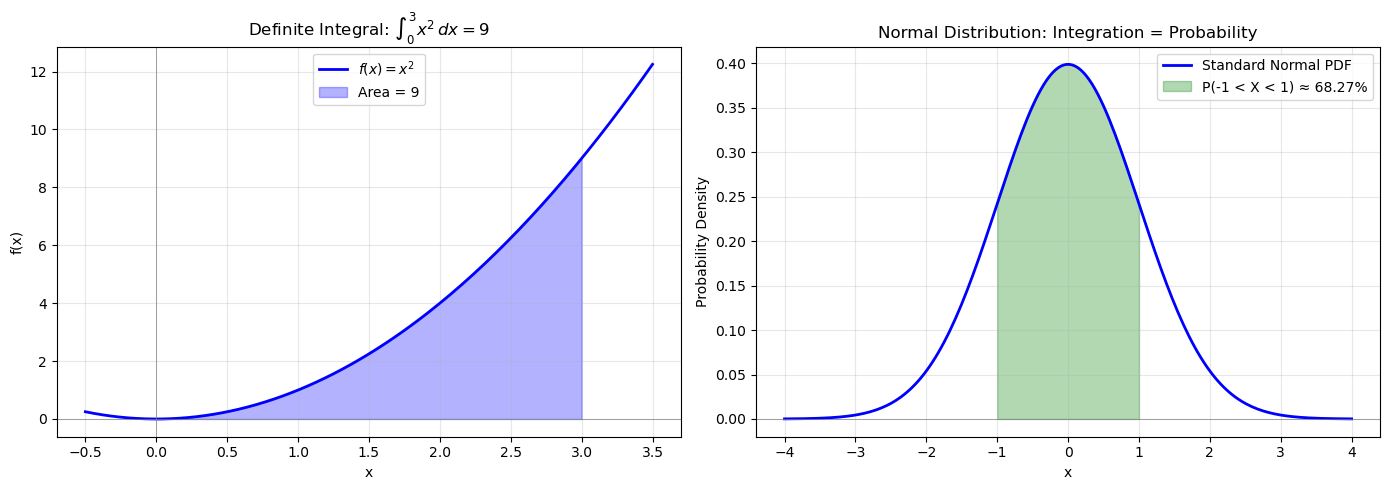

In [21]:
# ===============================================
# VISUALIZING INTEGRALS: AREA UNDER CURVE
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from sympy import *

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Area under parabola
ax1 = axes[0]
x_vals = np.linspace(-0.5, 3.5, 200)
y_vals = x_vals**2

ax1.plot(x_vals, y_vals, 'b-', linewidth=2, label=r'$f(x) = x^2$')

# Fill area from 0 to 3
x_fill = np.linspace(0, 3, 100)
y_fill = x_fill**2
ax1.fill_between(x_fill, y_fill, alpha=0.3, color='blue', label='Area = 9')

ax1.axhline(y=0, color='gray', linewidth=0.5)
ax1.axvline(x=0, color='gray', linewidth=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title(r'Definite Integral: $\int_0^3 x^2 \, dx = 9$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Normal distribution CDF
ax2 = axes[1]
x_vals2 = np.linspace(-4, 4, 200)
y_vals2 = (1/np.sqrt(2*np.pi)) * np.exp(-x_vals2**2/2)

ax2.plot(x_vals2, y_vals2, 'b-', linewidth=2, label='Standard Normal PDF')

# Fill area from -1 to 1 (68.27%)
x_fill2 = np.linspace(-1, 1, 100)
y_fill2 = (1/np.sqrt(2*np.pi)) * np.exp(-x_fill2**2/2)
ax2.fill_between(x_fill2, y_fill2, alpha=0.3, color='green', 
                label='P(-1 < X < 1) ≈ 68.27%')

ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel('Probability Density')
ax2.set_title('Normal Distribution: Integration = Probability')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ===============================================
# NUMERICAL INTEGRATION WITH NUMPY/SCIPY
# ===============================================

import numpy as np
from scipy import integrate

print("=" * 50)
print("NUMERICAL INTEGRATION")
print("=" * 50)

# Define a function
def f(x):
    return x**2

# Method 1: Trapezoidal rule with numpy
x_vals = np.linspace(0, 3, 100)
y_vals = f(x_vals)
area_trap = np.trapezoid(y_vals, x_vals)
print(f"\n1. Trapezoidal Rule: ∫₀³ x² dx ≈ {area_trap:.4f}")

# Method 2: Simpson's rule with scipy
area_simpson = integrate.simpson(y_vals, x=x_vals)
print(f"2. Simpson's Rule: ∫₀³ x² dx ≈ {area_simpson:.4f}")

# Method 3: Quadrature (adaptive integration)
area_quad, error = integrate.quad(f, 0, 3)
print(f"3. Quadrature: ∫₀³ x² dx ≈ {area_quad:.4f} (error: {error:.2e})")

print(f"\nExact value: 9.0000")

# More complex example that's hard to integrate analytically
print("\n" + "-" * 50)
print("Complex Integration Example:")

def complex_func(x):
    return np.exp(-x**2) * np.sin(x)**2

result, error = integrate.quad(complex_func, -np.inf, np.inf)
print(f"∫₋∞^∞ e^(-x²)·sin²(x) dx ≈ {result:.6f}")

NUMERICAL INTEGRATION

1. Trapezoidal Rule: ∫₀³ x² dx ≈ 9.0005
2. Simpson's Rule: ∫₀³ x² dx ≈ 9.0000
3. Quadrature: ∫₀³ x² dx ≈ 9.0000 (error: 9.99e-14)

Exact value: 9.0000

--------------------------------------------------
Complex Integration Example:
∫₋∞^∞ e^(-x²)·sin²(x) dx ≈ 0.560202


: 

---
# **Summary: Key Calculus Concepts for Data Science**

| Concept | Definition | Data Science Application |
|---------|------------|-------------------------|
| **Limits** | Value a function approaches | Foundation for derivatives |
| **Derivatives** | Rate of change | Gradient descent, optimization |
| **Partial Derivatives** | Rate of change w.r.t. one variable | Gradients in ML |
| **Chain Rule** | Differentiating compositions | Backpropagation |
| **Integrals** | Area under curve | Probability, expected values |

## SymPy Quick Reference

```python
from sympy import *
x = symbols('x')

# Limits
limit(f, x, a)              # lim(x→a) f(x)
limit(f, x, a, '+')         # Right-sided limit

# Derivatives
diff(f, x)                  # df/dx
diff(f, x, 2)               # d²f/dx²
diff(f, x, y)               # ∂²f/∂x∂y

# Integrals
integrate(f, x)             # Indefinite integral
integrate(f, (x, a, b))     # Definite integral from a to b
```